# Q8 — Does rating consistency or level vary by cuisine? *(extended)*

Groups venues by `primary_cuisine` (Tripadvisor vocabulary preferred) and compares mean
rating and mean multi-platform spread. Restricted to cuisines with enough venues to be
meaningful.

In [1]:
from analysis.notebook import *

Connected to ClickHouse db='dataman' at localhost:8123


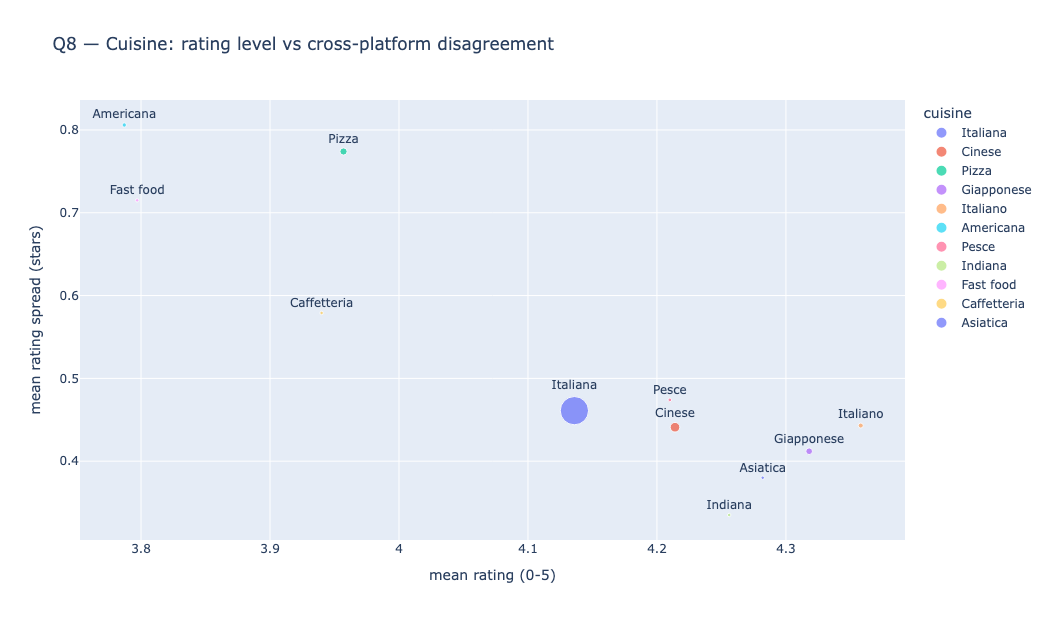

,cuisine,restaurants,mean_rating,multi_platform,mean_range
0,Italiana,2233,4.136,2229,0.461
1,Cinese,262,4.214,262,0.441
2,Pizza,144,3.957,144,0.774
3,Giapponese,125,4.318,124,0.412
4,Italiano,71,4.358,68,0.443
5,Americana,53,3.787,53,0.806
6,Pesce,38,4.210,38,0.474
7,Indiana,34,4.256,34,0.335
8,Fast food,34,3.797,34,0.715
9,Caffetteria,34,3.940,34,0.579


In [2]:
q8 = publish(run(queries.q8_cuisine(top_n=15, min_restaurants=30)), "q8_cuisine_consistency",
             "Q8 — Mean rating and cross-platform spread by primary cuisine.")
fig = px.scatter(q8, x="mean_rating", y="mean_range", size="restaurants", color="cuisine",
                 text="cuisine",
                 labels={"mean_rating": "mean rating (0-5)", "mean_range": "mean rating spread (stars)"},
                 title="Q8 — Cuisine: rating level vs cross-platform disagreement")
fig.update_traces(textposition="top center")
fig.show()
q8

**Answer (Q8):** Rating level and consistency **do vary by cuisine**. High-throughput,
broad-appeal categories (e.g. pizza, fast food / American) show the widest cross-platform
disagreement and lower mean ratings, while cuisines like Japanese sit higher-rated and more
consistent — see `q8_cuisine_consistency`.